# Determining electric conductivity $\sigma$ and magnetic field $B$

### Imports

In [1]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error


from python_utils.utils import load_object

from python_utils.yz_slice_utils import find_closest_coordinate_index

from python_utils.plotting import plot_timeseries

from python_utils.data_processing import print_yz_slice_example_from_parsed_data

from python_utils.sigma_and_b_estimation import calc_conductivity_with_z_at_site

### General Args

In [2]:
# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 1000

if Ha == 300:
    slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates from evaluations
sigma = -1
B_z = -1

### Load Data

In [3]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [ ]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
print_yz_slice_example_from_parsed_data(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
print_yz_slice_example_from_parsed_data(gradF_data)

Object successfully loaded from C:\Users\hydro\Documents\PhD\nuclear_fusion_cooling\data\4pi_re1000_ha1000.384.pi\SliceYZ_x0015\pkl\sliceYZ_x0015_fld.pkl
The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 49, n_z (grid width) = 49, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 y, first 2 z) with coordinates:
  (y=-1.00, z=-1.00): [ 0.         0.         0.        -0.2709205  0.         0.
 -0.0004302  0.290587 ]
  (y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.755902e-01  0.000000e+00
  4.372047e-01 -4.302696e-04  2.858409e-01]
  (y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.637546e-01 -3.491415e+00
  0.000000e+00 -4.098474e-04  3.136015e-01]
  (y=-0.99, z=-0.99): [-3.760981e+00  4.328748e-02 -1.042420e-01 -2.076186e-01  6.084429e-03
  2.005159e-01 -4.101349e-04  3.114591e-01]

Object successfully loaded from C:\Users\hydro\Documents\PhD\nucle

### Get Existing x and y Coordinates

In [5]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired

# Ha = 300
# y_coord = -0.01842125
# z_coord = -0.01842125

# Ha = 1000
y_coord = 0
z_coord = 0

i_y_center, i_z_center = find_closest_coordinate_index(
    fld_data['coord_to_index_map'],
    y_coord=y_coord,
    z_coord=z_coord,
    )

### Get $v_x$

In [6]:
v_x_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('vx'),
    ]

### Ohm's Law

$\mathbf{J} = \sigma (\mathbf{E} + \mathbf{v} \times \mathbf{B})$

In vector form:

$\mathbf{J} = \begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \begin{pmatrix} E_x + (v_y B_z - v_z B_y) \\ E_y + (v_z B_x - v_x B_z) \\ E_z + (v_x B_y - v_y B_x) \end{pmatrix}$

We know that $B$ is only present in $z$-direction.

$\begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \left(\begin{pmatrix}E_x \\ E_y \\ E_z \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\partial \varphi}{\partial x} \\ \frac{\partial \varphi}{\partial y} \\ \frac{\partial \varphi}{\partial 
z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$\approx \sigma \left(\begin{pmatrix} \frac{\Delta \varphi_x}{\Delta l_x} \\ \frac{\Delta \varphi_y}{\Delta l_y} \\ \frac{\Delta \varphi_z}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \\ \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} \\ \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

So, we have:

$ v_y \approx \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \right) $

$ v_x \approx \frac{1}{B_z} \left( \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} - \frac{j_y}{\sigma} \right) $

$ \frac{j_z}{\sigma} \approx \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z}$

### Estimate $B_z$

mean(B_z_est) = -0.9980944827931048
std(B_z_est) = 0.2520174405433839
median(B_z_est) = -0.9999044973269932


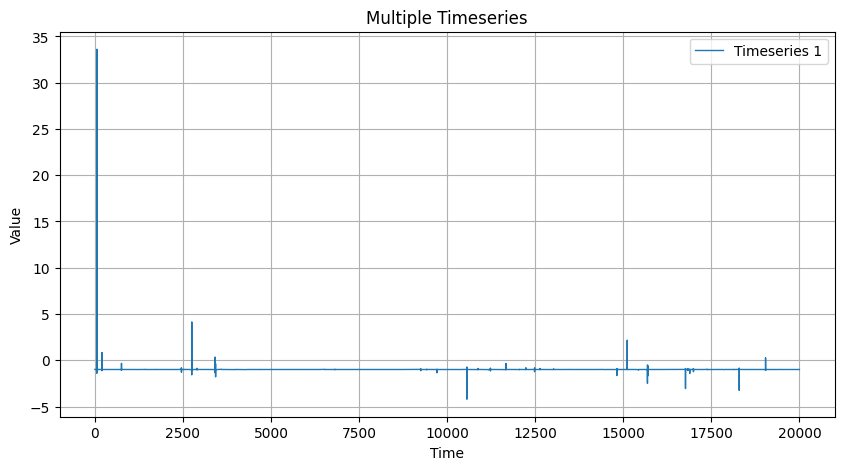

In [7]:
part_phi_y = gradF_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    gradF_data['labels'].index('dfdy'),
    ]
j_y_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('jy'),
    ]

B_z_est = np.divide(
    part_phi_y - j_y_center / sigma,
    # part_phi_y,
    v_x_center,
    )

print(f"mean(B_z_est) = {np.mean(B_z_est)}")
print(f"std(B_z_est) = {np.std(B_z_est)}")
print(f"median(B_z_est) = {np.median(B_z_est)}")

plot_timeseries(
    B_z_est,
    )

### Estimate Sigma

mean(sigma_est) = -0.5244395120905921
std(sigma_est) = 70.96016534811481
median(sigma_est) = -0.9719540985390813


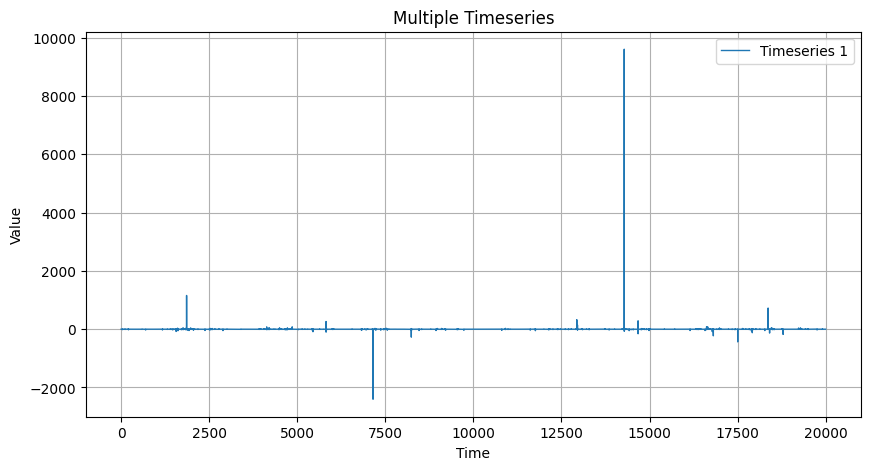

In [8]:
sigma_est = np.divide(
    j_y_center,
    part_phi_y - v_x_center * B_z,
    )

print(f"mean(sigma_est) = {np.mean(sigma_est)}")
print(f"std(sigma_est) = {np.std(sigma_est)}")
print(f"median(sigma_est) = {np.median(sigma_est)}")
plot_timeseries(
    sigma_est,
    )

## Ohm's Law in z-coord

### Calculate Sigma

In [9]:
sigma_est_ts = calc_conductivity_with_z_at_site(
        partial_phi_data=gradF_data,
        partial_phi_label='dfdz',
        current_data=fld_data,
        current_label='jz',
        y_idx=i_y_center,
        z_idx=i_z_center,
        print_statistics=True,
        )
# plot_timeseries(
#     sigma_est_ts,
#     )

mean(conductivity estimate) = -1.0
std(conductivity estimate) = 0.0
median(conductivity estimate) = -1.0


### Error in z

In [10]:
sigma_est_round = -1

part_phi_z = gradF_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    gradF_data['labels'].index('dfdz'),
    ]
j_z_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('jz'),
    ]

print(f"mse(part_phi_z) = {mean_squared_error(part_phi_z, j_z_center / sigma_est_round)}")

# plot_timeseries(
#     data_list=[
#         # part_phi_z,
#         part_phi_z - j_z_center / sigma_est_round,
#         ],
#     labels=[
#         # "$\\frac{\\partial{\\phi}}{\\partial{z}}$",
#         "err",
#         ],
#     )

mse(part_phi_z) = 0.0
